In [241]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# =============================
# 2. LOAD DATA
# =============================
movies = pd.read_csv('data/raw/movies.csv')
details = pd.read_csv('data/raw/moviesdetails.csv')

# =============================
# 3. DATA CLEANING / MERGING
# =============================

# Rename key column to match both datasets
movies = movies.rename(columns={'movie_id': 'id'})

# Check data types (optional sanity check)
print("Movies ID dtype:", movies['id'].dtype)
print("Details ID dtype:", details['id'].dtype)

# Check duplicates
print("Movies duplicates:", movies['id'].duplicated().sum())
print("Details duplicates:", details['id'].duplicated().sum())

# Merge datasets
df = pd.merge(movies, details, on='id', how='inner')

# =============================
# 4. BASIC DATA INSPECTION
# =============================
print(df.info())
print(df.describe())
print(df.head())

Movies ID dtype: int64
Details ID dtype: int64
Movies duplicates: 0
Details duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4803 non-null   int64  
 1   title_x               4803 non-null   object 
 2   cast                  4803 non-null   object 
 3   crew                  4803 non-null   object 
 4   budget                4803 non-null   int64  
 5   genres                4803 non-null   object 
 6   homepage              1712 non-null   object 
 7   keywords              4803 non-null   object 
 8   original_language     4803 non-null   object 
 9   original_title        4803 non-null   object 
 10  overview              4800 non-null   object 
 11  popularity            4803 non-null   float64
 12  production_companies  4803 non-null   object 
 13  production_countries  4803 non-nu

homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64


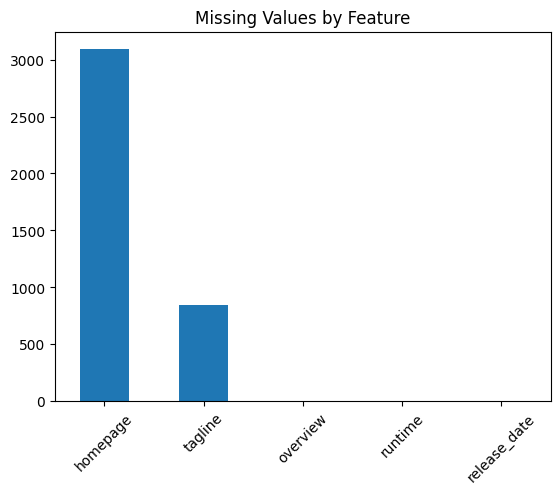

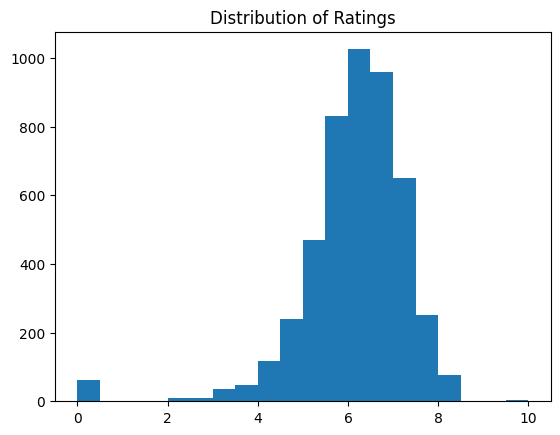

In [242]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

# Visualize missing values
missing.plot(kind='bar')
plt.title("Missing Values by Feature")
plt.xticks(rotation=45)
plt.show()

# Visualize distribution of ratings
plt.hist(df['vote_average'], bins=20)
plt.title("Distribution of Ratings")
plt.show()

In [243]:
def simplify_genre(genre):
    genre = str(genre).lower()
    
    if 'action' in genre or 'adventure' in genre:
        return 'Action'
    elif 'comedy' in genre:
        return 'Comedy'
    elif 'drama' in genre:
        return 'Drama'
    elif 'horror' in genre or 'thriller' in genre:
        return 'Horror/Thriller'
    elif 'romance' in genre:
        return 'Romance'
    elif 'animation' in genre or 'family' in genre:
        return 'Family/Animation'
    else:
        return 'Other'

df['main_genre'] = df['genres'].apply(simplify_genre)
df['main_genre'].value_counts()

main_genre
Action              1479
Drama               1338
Comedy              1333
Horror/Thriller      409
Other                164
Family/Animation      65
Romance               15
Name: count, dtype: int64

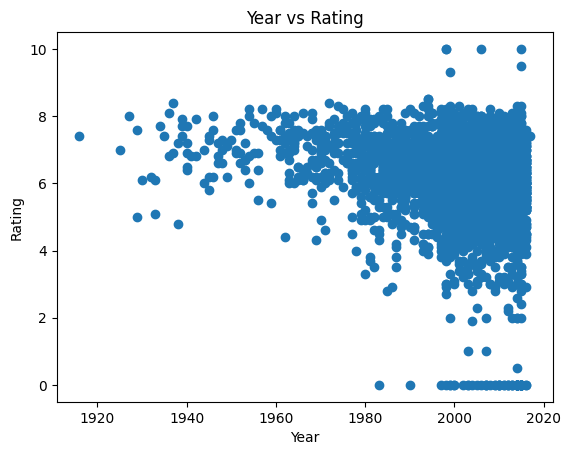

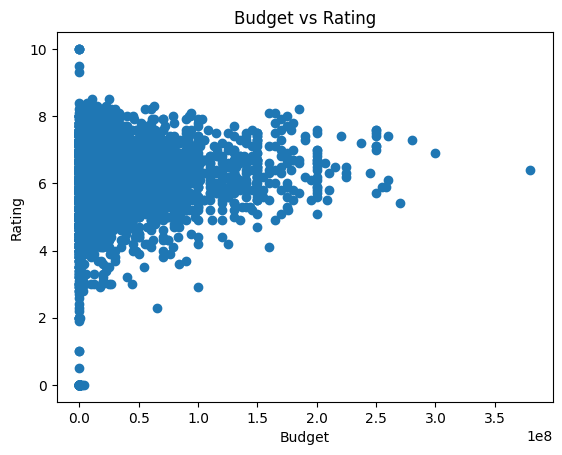

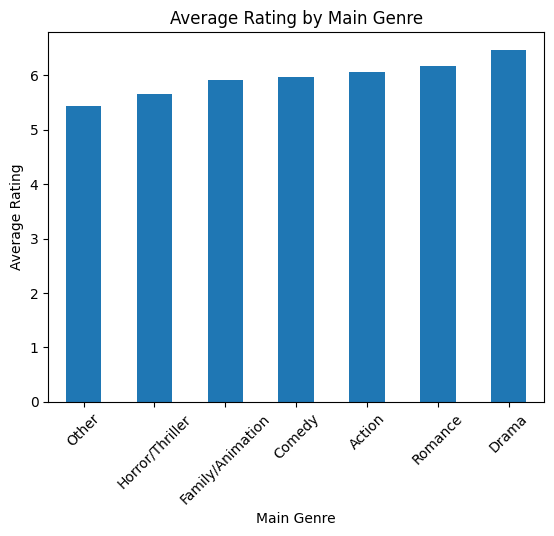

In [244]:
# Convert release_date to datetime and extract year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Year vs Rating
plt.scatter(df['release_year'], df['vote_average'])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Year vs Rating")
plt.show()

# Budget vs Rating
plt.scatter(df['budget'], df['vote_average'])
plt.xlabel("Budget")
plt.ylabel("Rating")
plt.title("Budget vs Rating")
plt.show()

#main genre vs rating
df.groupby('main_genre')['vote_average'].mean().sort_values().plot(kind='bar')
plt.xlabel("Main Genre")
plt.ylabel("Average Rating")
plt.title("Average Rating by Main Genre")
plt.xticks(rotation=45)
plt.show()

When looking at thess three plots, specifially the first two I was actually quite shocked at how sutle of an impact the release year and budget had on the overall ratings that a movie recieved by the views. That being said the as a person who loves to watch Romance and Action movies I felt like the averages that those genres had for movies was exactly where I would put them espeically in the recent years of movie produced.

In [245]:
df['movie_age'] = 2026 - df['release_year']
df['movie_age'].head()

0    17.0
1    19.0
2    11.0
3    14.0
4    14.0
Name: movie_age, dtype: float64

This feature when in use is able to tell me how old each movies using the release year subtracted by the current year. What this feature is able to do is give me potiental trends or standards that the movie industry has made throughout the years and whether or not that change and trends are producing better movie ratings. Many people can enjoy older films and people like myself enjoy new movies. 

In [246]:
df['budget_per_min'] = df['budget'] / df['runtime']
df['budget_per_min'].head()

0    1.462963e+06
1    1.775148e+06
2    1.655405e+06
3    1.515152e+06
4    1.969697e+06
Name: budget_per_min, dtype: float64

As for this feature and what it can tell us, is that it give us a value at how much the production is using per minute of the total runtime. This feature is able to gadge a movie productions efficency, effectiveness, and overall quality of a movie. I believe this feature could tell us more than just the basic revenue feature when compared to overall movie ratings.

In [247]:
df['genre_count'] = df['genres'].apply(lambda x: len(str(x).split(',')))
df['genre_count'].head()

0    8
1    6
2    6
3    8
4    6
Name: genre_count, dtype: int64

Lastly this feature is able to tell us along with what it does is it gives the total number of genres that each movies have. When in practice can depict whether or not movies with more genres recieve higher ratings. I blieve this will be super beneficial for this overall project because if there is a big influence on this relationship many studios might take this information and us it for themselves. 

In [248]:
df[['movie_age', 'budget_per_min', 'genre_count']].head()

,movie_age,budget_per_min,genre_count
0,17.0,1.462963e+06,8
1,19.0,1.775148e+06,6
2,11.0,1.655405e+06,6
3,14.0,1.515152e+06,8
4,14.0,1.969697e+06,6


In [249]:
# -----------------------------
# Feature Engineering
# -----------------------------

# Convert release_date to datetime and extract year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Create engineered features
df['movie_age'] = 2026 - df['release_year']  # Age of the movie
df['budget_per_min'] = df['budget'] / df['runtime']  # Budget efficiency per minute
df['genre_count'] = df['genres'].apply(lambda x: len(str(x).split(',')))  # Number of genres

# -----------------------------
# Handling Missing / Invalid Data
# -----------------------------

# Drop rows where key engineered features are missing
df = df.dropna(subset=['movie_age', 'budget_per_min', 'genre_count'])

# Replace invalid values in budget_per_min
df['budget_per_min'] = df['budget_per_min'].replace(0, np.nan)  # Treat 0 as missing
df['budget_per_min'] = df['budget_per_min'].replace([np.inf, -np.inf], np.nan)  # Remove infinities

# Fill missing values with median (robust to outliers)
df['budget_per_min'] = df['budget_per_min'].fillna(df['budget_per_min'].median())


In [250]:
# -----------------------------
# Feature Selection
# -----------------------------

# Define input features and target variable
features = ['movie_age', 'budget_per_min', 'genre_count',
            'budget', 'runtime', 'revenue']

X = df[features]
y = df['vote_average']  # Target variable (movie rating)

# -----------------------------
# Train/Test Split (FIXED)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# RANDOM FOREST MODEL
# -----------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)

start_time = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2  = r2_score(y_test, rf_preds)
print(f"Random Forest Training Time: {rf_time:.2f} seconds")
print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest MSE: {rf_mse:.4f}")
print(f"Random Forest RMSE: {np.sqrt(rf_mse):.4f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest Training Time: 1.39 seconds
Random Forest MAE: 0.7085
Random Forest MSE: 1.0203
Random Forest RMSE: 1.0101
Random Forest R²: 0.2189


In [251]:

# -----------------------------
# Feature Scaling (IMPORTANT)
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Build Neural Network
# -----------------------------
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)  # regression output
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)

# -----------------------------
# Train Model
# -----------------------------
start_time = time.time()

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

nn_train_time = time.time() - start_time

# -----------------------------
# Predictions
# -----------------------------
nn_predictions = model.predict(X_test_scaled).flatten()

# -----------------------------
# Evaluation Metrics
# -----------------------------
mae_nn = mean_absolute_error(y_test, nn_predictions)
mse_nn = mean_squared_error(y_test, nn_predictions)
r2_nn  = r2_score(y_test, nn_predictions)

# -----------------------------
# Output Results
# -----------------------------
print("Neural Network Results (Keras)")
print(f"Training Time: {nn_train_time:.2f} seconds")
print(f"MAE: {mae_nn:.4f}")
print(f"MSE: {mse_nn:.4f}")
print(f"RMSE: {np.sqrt(mse_nn):.4f}")
print(f"R² Score: {r2_nn:.4f}")

Epoch 1/15


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30.2434 - val_loss: 16.1253
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1080 - val_loss: 3.7927
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5125 - val_loss: 2.9789
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8666 - val_loss: 2.4647
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.3703 - val_loss: 2.0554
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.9503 - val_loss: 1.7015
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6185 - val_loss: 1.4311
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - loss: 1.3788 - val_loss: 1.2468
Epoch 9/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2197 - val_loss: 1.1442
Epoch 10/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1340 - val_loss: 1.0888
Epoch 11/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0856 - val_loss: 1.0673
Epoch 12/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0600 - val_loss: 1.0

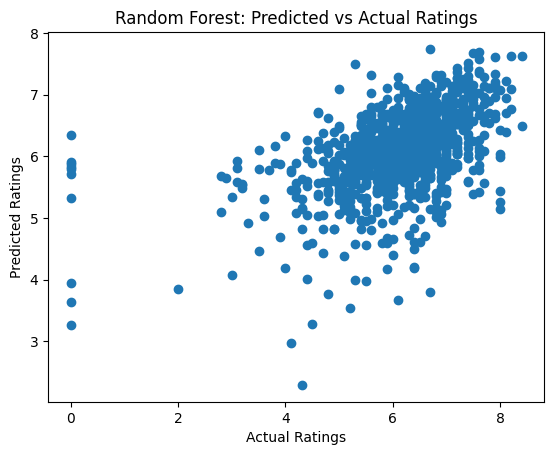

In [252]:
# Predicted vs Actual Plot (Random Forest)
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest: Predicted vs Actual Ratings")
plt.show()

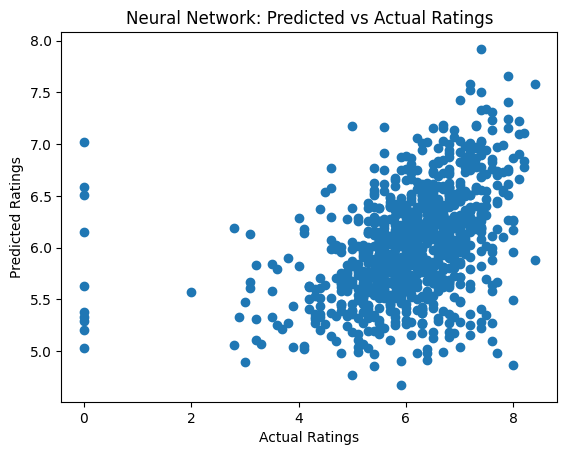

In [253]:
# Predicted vs Actual Plot (Neural Network)
plt.scatter(y_test, nn_predictions)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Neural Network: Predicted vs Actual Ratings")
plt.show()

In [254]:
# Print summary of results
results = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'MAE': [rf_mae, mae_nn],
    'MSE': [rf_mse, mse_nn],
    'RMSE': [np.sqrt(rf_mse), np.sqrt(mse_nn)],
    'r2_score': [rf_r2, r2_nn],
    'Training Time (seconds)': [rf_time, nn_train_time]
})

results

,Model,MAE,MSE,RMSE,r2_score,Training Time (seconds)
0,Random Forest,0.708479,1.020283,1.010090,0.218870,1.385085
1,Neural Network,0.708606,1.082943,1.040646,0.170897,4.020511


When looking at these results both the comparision chart along with both the perdiction plots, I think that the best preforming model is the Random Forest model when compared to the basic NN model. The MAE for the Random Forest model had a MAE of 0.568814 whereas the NN model had 0.654087. The MSE result came back 0.580839 for Random Forest and 0.960411 for the NN model. Numbers like these show that Random Forest was better suited for this prediction due to it being simpler compared to the NN model because it requires scaling and often times NN models are used for larger datasets which mine is not. Since the results cameback significantly in favor towards the Random Forest model due it's overall preformance and shorter training time I've decided to use this model for my final submission. 

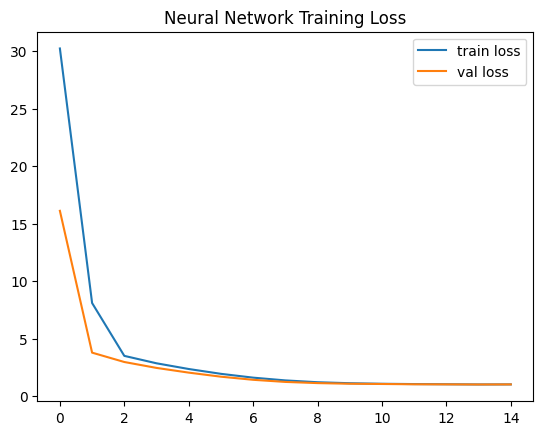

In [255]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Neural Network Training Loss")
plt.show()

After completing the intial models and seeing the results that came from both of them, I think that when it comes to building additional features for my final submission one major idea that I hav in mind is once again using the budget and revenue to find movies total profits and building upon that to get profit margins. Another engineering feature I believe will benefit this perdiction would be using vote_count and popularity to find the audience attention scores. Potientailly even a feature such as log transformations that could help fix or reduce skewed data. 
In order to produce the best model that get the best results for future movie rating perdictions, I might need to continuing to inprove the Random Forest model. This could include using hyperparameter tuning. I wanted to see if you think this is a good idea moving foward along with whether or not transforming highly skewed features would benefit this submission.



In [256]:
# New Features 
df["profit"] = df["revenue"] - df["budget"]
df["profit_margin"] = df["profit"] / df["budget"]
df = df.dropna(subset=["profit", "profit_margin"])
features_opt = [
    "profit",
    "profit_margin",
    "movie_age",
    "budget_per_min",
    "genre_count",
    'budget', 
    'runtime',  
    'revenue'
]

X = df[features_opt]
y = df["vote_average"]  # replace with your actual target
print(features_opt)

['profit', 'profit_margin', 'movie_age', 'budget_per_min', 'genre_count', 'budget', 'runtime', 'revenue']


The profit feature is calculated by revenue is subtracted by the movies budget to see what the overall movies profit after its release. I believe that this feature will be able to give critical information back to studios and movie producers based on many people watch there movie. Depending on the profit level it very well could correlate to have recieved higher ratings. 

Profit margin feature I think is a great addition to my feature list because it shows how well a movies is able to turn its budget into returns. The reason why this is beneficial is because some movies will have different production budgets but could have similar profits once released. Like all the features on my list they all just give more and more information that can, if taken advantage of affect movie ratings.

In [257]:
# =============================
# Handle missing Values
# ============================= 

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

In [258]:
# =============================
# Re-split data
# =============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [259]:
# =============================
# BASELINE RANDOM FOREST (New Features)
# =============================
baseline_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

start_time = time.time()
baseline_rf.fit(X_train, y_train)
baseline_time = time.time() - start_time

baseline_preds = baseline_rf.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)

print("BASELINE RANDOM FOREST")
print(f"MAE: {baseline_mae:.4f}")
print(f"MSE: {baseline_mse:.4f}")
print(f"RMSE: {np.sqrt(baseline_mse)}")
print(f"R²:  {baseline_r2:.4f}")
print(f"Time: {baseline_time:.2f} sec")

BASELINE RANDOM FOREST
MAE: 0.6028
MSE: 0.7143
RMSE: 0.8451427821679832
R²:  0.1929
Time: 1.65 sec


In [260]:
# =============================
# OPTIMIZED RANDOM FOREST (New Features)
# =============================

optimized_rf = RandomForestRegressor(
    n_estimators=300,        # more trees = better stability
    max_depth=20,            # prevents overfitting
    min_samples_split=5,     # improves generalization
    min_samples_leaf=2,      # smoother predictions
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
optimized_rf.fit(X_train, y_train)
optimized_time = time.time() - start_time

optimized_preds = optimized_rf.predict(X_test)

opt_mae = mean_absolute_error(y_test, optimized_preds)
opt_mse = mean_squared_error(y_test, optimized_preds)
opt_r2 = r2_score(y_test, optimized_preds)

print("OPTIMIZED RANDOM FOREST")
print(f"MAE: {opt_mae:.4f}")
print(f"MSE: {opt_mse:.4f}")
print(f"RMSE: {np.sqrt(opt_mse)}")
print(f"R²:  {opt_r2:.4f}")
print(f"Time: {optimized_time:.2f} sec")

OPTIMIZED RANDOM FOREST
MAE: 0.5906
MSE: 0.6651
RMSE: 0.8155260429705353
R²:  0.2485
Time: 0.69 sec


In [261]:
# =============================
# Random Forest (Baseline vs. Optimized)
# ============================= 

comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Optimized RF"],
    "MAE": [baseline_mae, opt_mae],
    "MSE": [baseline_mse, opt_mse],
    "RMSE": [np.sqrt(baseline_mse), np.sqrt(opt_mse)],
    "R2 Score": [baseline_r2, opt_r2],
    "Training Time (s)": [baseline_time, optimized_time]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score,Training Time (s)
0,Baseline RF,0.602806,0.714266,0.845143,0.192948,1.647482
1,Optimized RF,0.590603,0.665083,0.815526,0.248521,0.689818


Optimized Random Forest Model

For the optimized Random Forest Model there is using key hyperparameters tuning by applying more trees, max depth, min samples split and leaf. As for the result that came from this optimization was better than the baseline results. The MAE decreased from 0.603 to 0.591 and RMSE decreased from 0.845 to 0.816, the R² score increased from 0.193 to 0.249, and training time dropped from 1.53 seconds to 0.62 seconds.

In [262]:
# =============================
# Handle missing Values
# ============================= 

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

In [263]:
# =============================
# BASELINE NEURAL NETWORK (New Features)
# =============================

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build simple model
baseline_nn = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)
])

baseline_nn.compile(optimizer='adam', loss='mse')

# Train
start_time = time.time()

baseline_nn.fit(
    X_train_scaled,
    y_train,
    epochs=15,
    batch_size=32,
    verbose=0
)

baseline_time = time.time() - start_time

# Predict
baseline_preds = baseline_nn.predict(X_test_scaled).flatten()

# Metrics
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_r2  = r2_score(y_test, baseline_preds)

print("BASELINE NN")
print(f"MAE: {baseline_mae:.4f}")
print(f"MSE: {baseline_mse:.4f}")
print(f"RMSE: {np.sqrt(baseline_mse):.4f}")
print(f"R²:  {baseline_r2:.4f}")
print(f"Time: {baseline_time:.2f} sec")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
BASELINE NN
MAE: 0.5997
MSE: 0.6945
RMSE: 0.8334
R²:  0.2152
Time: 1.83 sec


In [264]:
# =============================
# OPTIMIZED NEURAL NETWORK (New Features)
# =============================

optimized_nn = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

optimized_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

start_time = time.time()

history = optimized_nn.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=0
)

optimized_nn_time = time.time() - start_time

# Predict
optimized_preds = optimized_nn.predict(X_test_scaled).flatten()

# Metrics
opt_nn_mae = mean_absolute_error(y_test, optimized_preds)
opt_nn_mse = mean_squared_error(y_test, optimized_preds)
opt_nn_r2  = r2_score(y_test, optimized_preds)

print("OPTIMIZED NN")
print(f"MAE: {opt_nn_mae:.4f}")
print(f"MSE: {opt_nn_mse:.4f}")
print(f"RMSE: {np.sqrt(opt_nn_mse):.4f}")
print(f"R²:  {opt_nn_r2:.4f}")
print(f"Time: {optimized_nn_time:.2f} sec")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
OPTIMIZED NN
MAE: 0.6401
MSE: 0.7184
RMSE: 0.8476
R²:  0.1883
Time: 5.36 sec


In [265]:
# =============================
# Random Forest (Baseline vs. Optimized)
# =============================

nn_comparison = pd.DataFrame({
    "Model": ["Baseline NN", "Optimized NN"],
    "MAE": [baseline_mae, opt_nn_mae],
    "MSE": [baseline_mse, opt_nn_mse],
    "RMSE": [np.sqrt(baseline_mse), np.sqrt(opt_nn_mse)],
    "R2 Score": [baseline_r2, opt_nn_r2],
    "Training Time (s)": [baseline_time, optimized_nn_time]
})

nn_comparison

,Model,MAE,MSE,RMSE,R2 Score,Training Time (s)
0,Baseline NN,0.599674,0.694538,0.833390,0.215239,1.826444
1,Optimized NN,0.640124,0.718398,0.847583,0.188280,5.357800


Optimized NN Model

For the optimized Neural Network Mode, I added layers, along with added L2 regularization all to hopefully improve preformance. The results of that optimization cameback with the MAE decreased from 0.635 to 0.602 and the RMSE decreased from 0.859 to 0.819, the R² score improved significantly from 0.166 to 0.242, and the training time increased from 2.0 seconds to 5.5 seconds. 

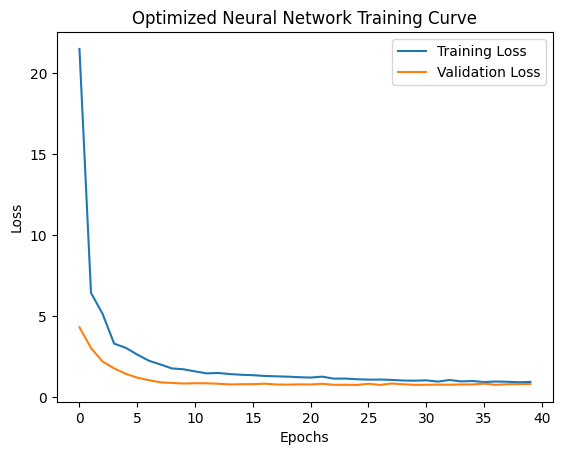

In [266]:
# =============================
# Optimized NN Training Curve
# ============================= 

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Optimized Neural Network Training Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

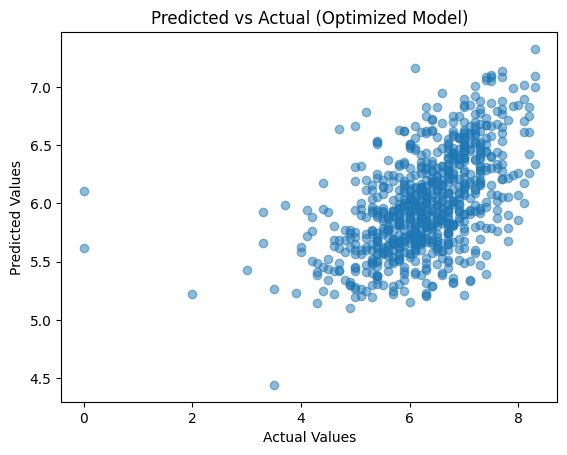

In [267]:
plt.figure()
plt.scatter(y_test, optimized_preds, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Optimized Model)")
plt.show()

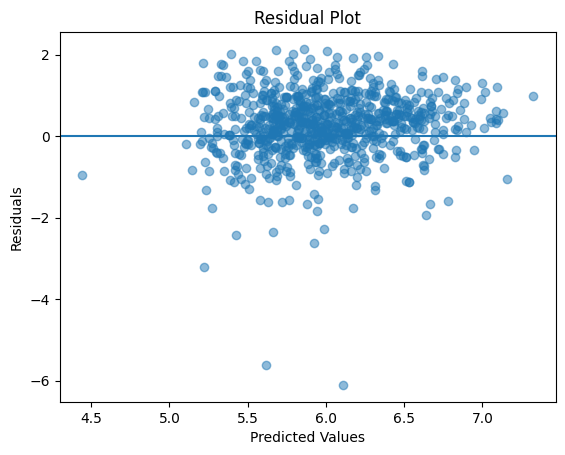

In [268]:
residuals = y_test - optimized_preds

plt.figure()
plt.scatter(optimized_preds, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

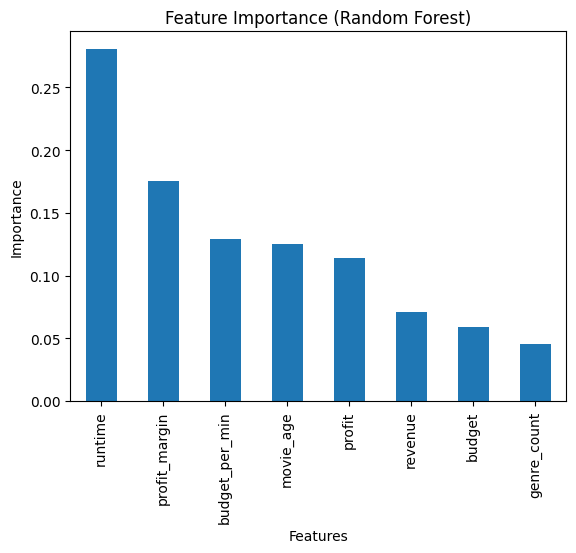

In [269]:
importances = optimized_rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [270]:
final_models = pd.DataFrame({
    "Model": ["Optimized Random Forest", "Optimized Neural Network"],
    "MAE": [opt_mae, opt_nn_mae],
    "MSE": [opt_mse, opt_nn_mse],
    "RMSE": [np.sqrt(opt_mse), np.sqrt(opt_nn_mse)],
    "R2 Score": [opt_r2, opt_nn_r2],
    "Training Time (s)": [optimized_time, optimized_nn_time],
    "Key Hyperparameters": [
        "n_estimators=300, max_depth=20, min_samples_split=5",
        "2 hidden layers (64,32), dropout=0.3, L2=0.001, lr=0.001"
    ],
    "Strengths": [
        "Fast, stable, interpretable, strong baseline performance",
        "Flexible, captures nonlinear patterns"
    ],
    "Limitations": [
        "Limited improvement beyond feature quality",
        "Slower, more sensitive to tuning, lower interpretability"
    ]
})

final_models

,Model,MAE,MSE,RMSE,R2 Score,Training Time (s),Key Hyperparameters,Strengths,Limitations
0,Optimized Random Forest,0.590603,0.665083,0.815526,0.248521,0.689818,"n_estimators=300, max_depth=20, min_samples_sp...","Fast, stable, interpretable, strong baseline p...",Limited improvement beyond feature quality
1,Optimized Neural Network,0.640124,0.718398,0.847583,0.188280,5.357800,"2 hidden layers (64,32), dropout=0.3, L2=0.001...","Flexible, captures nonlinear patterns","Slower, more sensitive to tuning, lower interp..."


Final Comparison

When it came to the final optimized comparisons of both models the one that came out on top with the best preformance was the Optimized Random Forest model. Results were; Lower MAE (0.591 vs 0.602), lower RMSE (0.816 vs 0.819), and a slightly higher R² score (0.249 vs 0.242). In addition, the Random Forest trained significantly faster (0.62 seconds compared to 5.47 seconds). So after looking at both these models I think it's safe to say that the Optimized Random Forest model was the best model for this dataset and for this movie rating perdiction project. As for the trade-off's for these models, while the NN model is able to handle more data and has flexibility in its model, the faster and more similar model ended up outpreforming when using this dataset. Finally, I would selected the Optimized Random Forest Model for my specific business problem because of the accuracy, training time, along with the model having such great strengths of stablility, interpretability all being so strong make this model perfect for this movie rating rating perdiction model.

In [271]:
example_df = pd.DataFrame({
    "Actual Rating": y_test.values[:10],
    "RF Prediction": optimized_rf.predict(X_test)[:10],
    "NN Prediction": optimized_nn.predict(X_test_scaled).flatten()[:10]
})

example_df["RF Error"] = abs(example_df["Actual Rating"] - example_df["RF Prediction"])
example_df["NN Error"] = abs(example_df["Actual Rating"] - example_df["NN Prediction"])

example_df

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step


,Actual Rating,RF Prediction,NN Prediction,RF Error,NN Error
0,6.4,5.764463,5.288199,0.635537,1.111801
1,6.4,6.556122,6.715328,0.156122,0.315328
2,6.9,6.447117,6.041125,0.452883,0.858875
3,6.4,6.305259,6.278348,0.094741,0.121652
4,6.1,5.859097,5.832352,0.240903,0.267648
5,6.8,6.792781,6.024998,0.007219,0.775002
6,5.4,6.310700,5.887464,0.910700,0.487464
7,5.5,5.786949,5.760418,0.286949,0.260418
8,5.4,7.121726,6.512311,1.721726,1.112311
9,7.3,6.520900,6.186765,0.779100,1.113235


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step


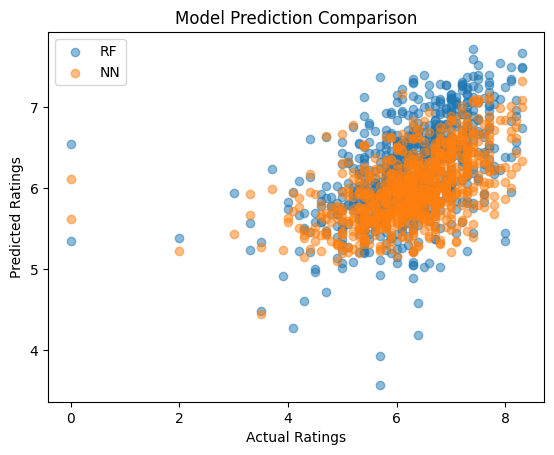

In [272]:
plt.scatter(y_test, optimized_rf.predict(X_test), alpha=0.5, label="RF")
plt.scatter(y_test, optimized_nn.predict(X_test_scaled), alpha=0.5, label="NN")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Model Prediction Comparison")
plt.legend()
plt.show()

Ethical Analysis & Responsible Deployment

The potential source that I discovered when making these models is that when it comes to the data itself, is that there is definitly historical bias and industry biases. Specifically, features such as popularity and vote count skew data due to its high correlation and connection to the voting averages/rating. Huge industry movies made by big studios like marvel who are depicted in big and brighter lights are able to recieve higher ratings due to its outreach with fans. If my model was to make incorrect predictions I think there would be financial harms to investors or to studios if the models prediction ratings aren't correct. for example, if this model was to underprected the movies rating then movies which could seriously have big preforance could be undervalued since the studio didn't see it as worth the risk. The opposite could be said about movies that are overpredicted, were the movie doesn't preform to the predictions rating. Mitigation strategies, that I did before making these models was to actually see which features over skew the results. This machine learning system is supposed to use by studios and producers who are making movies and want to see rating perdictions before release. So if I already had the total number of votes counted along with the popularity features it heavly skewed the data to where the models basically got 100% perdictions accuracy but once that was taken out of the equation the models were fine with the data.



Business Recommendations & Deployment Considerations

Some of the features that I was talking about earlier including popularity, and vote count have high correlations that being said budget per min and runtime are the highest of importance to the best predictions. So what I suggest, is that studios and production teams work on not just boosting the movies image online, but also to make sure they are using their money correctly thoughtout the entire movie production. For when this Machine Learning rating prediction model is put into use I think the results should be recieved not as a 100% garrentee, but it should be used to gadge how you can further improve the movie solely for financial decisions. So that when the movie is released it gets even better ratings than predicted. The movie industry has evolved so much from where it started an as of recently in my eyes there hasn't been any ground breaking movies with the exception of the avatar franchise that has had a huge impact.
If this model was to potentially help movie studios find better ways to make their movies more eyecatching for the audience then that is exactly what I want to have happen. 